# Phase 4: Evaluation

**Goal:** Compare T-Learner and X-Learner using proper uplift evaluation metrics.

Standard AUC cannot be used here because there is no per-user ground truth label for uplift. Each user is observed in only one state (treated or control), never both. Instead we use two uplift-specific approaches:

- **Qini AUC and AUUC:** scalar metrics that measure how much of the total observed uplift is captured by targeting the top-ranked users. Both compute the area between the model curve and a random targeting baseline, differing only in y-axis normalization.
- **Uplift by decile:** splits users into 10 buckets by predicted uplift score and computes the actual observed visit lift per bucket. A good model should show clearly higher lift in the top deciles and lower or near-zero lift in the bottom deciles.

**Inputs:**
- `data/tlearner_scores.parquet`
- `data/xlearner_scores.parquet`

**Outputs:**
- `images/qini_curve.png`
- `images/uplift_by_decile.png`

## 1. Setup

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklift.metrics import qini_auc_score, qini_curve, uplift_auc_score

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Scores

Both score files share the same format: `uplift`, `y_true`, `treatment`. They cover the exact same 1.4M test users from the same `random_state=1` split, so the comparison is apples-to-apples.

In [2]:
df_t = pd.read_parquet("../data/tlearner_scores.parquet")
df_x = pd.read_parquet("../data/xlearner_scores.parquet")

print("T-Learner scores:", df_t.shape)
print("X-Learner scores:", df_x.shape)
df_t.head()

T-Learner scores: (1397960, 3)
X-Learner scores: (1397960, 3)


,uplift,y_true,treatment
0,-0.017954,0,1
1,0.003411,0,0
2,0.000720,0,0
3,-0.002254,0,1
4,0.007887,0,1


## 3. Qini Curve

The Qini curve plots cumulative incremental visit uplift as we target an increasing fraction of users, ordered by predicted uplift score from highest to lowest. The diagonal represents random targeting (no model). A model that correctly identifies persuadables will curve above the diagonal, capturing more uplift with fewer users targeted. Both models are plotted on the same chart for direct comparison.

At each step along the x-axis, the y value is computed as:

```
incremental_visits = visits_in_treatment_so_far - visits_in_control_so_far × (n_treatment_total / n_control_total)
```

The ratio adjustment accounts for the 85/15 treatment/control imbalance. Without it, y would grow faster simply because there are far more treated users than control users.

At x = 1.0 (all users targeted), y reaches the total incremental visits among treated users in the test set (~12,287), approximately ATE × N_treatment ≈ 0.0103 × 1,188,266.

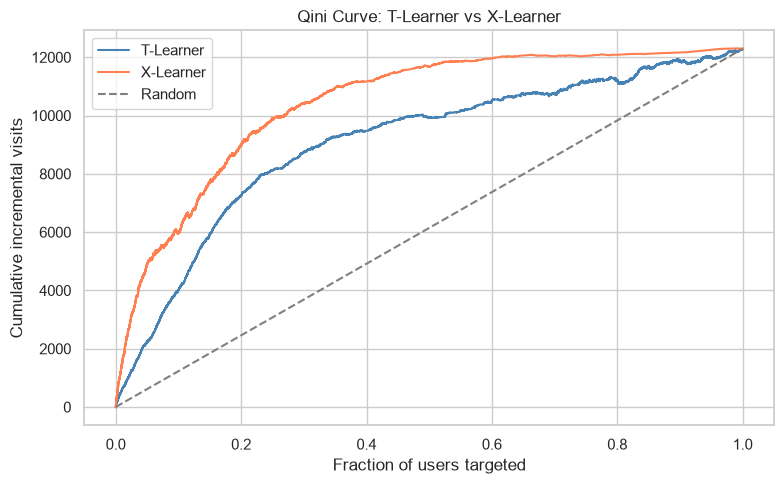

In [3]:
x_t, y_t = qini_curve(df_t["y_true"], df_t["uplift"], df_t["treatment"])
x_x, y_x = qini_curve(df_x["y_true"], df_x["uplift"], df_x["treatment"])

# normalize x to fraction of users targeted (0 to 1)
x_t_norm = x_t / x_t.max()
x_x_norm = x_x / x_x.max()

plt.figure(figsize=(8, 5))
plt.plot(x_t_norm, y_t, color="steelblue", label="T-Learner")
plt.plot(x_x_norm, y_x, color="coral", label="X-Learner")
plt.plot([0, 1], [0, y_t[-1]], color="gray", linestyle="--", label="Random")
plt.xlabel("Fraction of users targeted")
plt.ylabel("Cumulative incremental visits")
plt.title("Qini Curve: T-Learner vs X-Learner")
plt.legend()
plt.tight_layout()
plt.savefig("../images/qini_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
checkpoints = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for cp in checkpoints:
    idx_t = np.searchsorted(x_t_norm, cp)
    idx_x = np.searchsorted(x_x_norm, cp)
    y_t_val = round(y_t[min(idx_t, len(y_t) - 1)])
    y_x_val = round(y_x[min(idx_x, len(y_x) - 1)])
    rows.append({
        "Fraction targeted": f"{cp:.0%}",
        "T-Learner incremental visits": y_t_val,
        "X-Learner incremental visits": y_x_val,
        "X-Learner advantage": f"{(y_x_val - y_t_val) / y_t_val * 100:.0f}%",
    })

pd.DataFrame(rows)

,Fraction targeted,T-Learner incremental visits,X-Learner incremental visits,X-Learner advantage
0,20%,7248,8968,24%
1,40%,9493,11168,18%
2,60%,10513,11968,14%
3,80%,11211,12082,8%
4,100%,12287,12287,0%


Both models beat random targeting, confirming real signal in both learners. X-Learner stays clearly above T-Learner across the full curve.

The X-Learner advantage is front-loaded: 24% more incremental visits at the top 20% (8,968 vs 7,248), shrinking to 8% at 80%. In a budget-constrained campaign targeting only the top users, X-Learner delivers meaningfully more value.

Both curves flatten sharply after 60%. The bottom 40% of ranked users adds only 319 more incremental visits for X-Learner (2.6% of ceiling) and 1,774 for T-Learner, consistent with near-zero treatment effect for the majority of the population. At 100% targeting, both models converge to 12,287 incremental visits.

## 4. Qini AUC and AUUC

Two scalar metrics summarize ranking quality:

- **Qini AUC** (`qini_auc_score`): area between the Qini curve and random baseline. Y-axis: `Y_T - Y_C × (N_T / N_C)`.
- **AUUC** (`uplift_auc_score`): area between the uplift curve and random baseline. Y-axis: `(Y_T/N_T - Y_C/N_C) × (N_T + N_C)`.

Both measure the same ranking quality with different y-axis normalizations.

In [5]:
auc_t  = qini_auc_score(df_t["y_true"], df_t["uplift"], df_t["treatment"])
auc_x  = qini_auc_score(df_x["y_true"], df_x["uplift"], df_x["treatment"])
auuc_t = uplift_auc_score(df_t["y_true"], df_t["uplift"], df_t["treatment"])
auuc_x = uplift_auc_score(df_x["y_true"], df_x["uplift"], df_x["treatment"])

print(f"{'Metric':<12} {'T-Learner':>12} {'X-Learner':>12} {'Improvement':>12}")
print("-" * 50)
print(f"{'Qini AUC':<12} {auc_t:>12.4f} {auc_x:>12.4f} {(auc_x - auc_t) / auc_t * 100:>11.1f}%")
print(f"{'AUUC':<12} {auuc_t:>12.4f} {auuc_x:>12.4f} {(auuc_x - auuc_t) / auuc_t * 100:>11.1f}%")

Metric          T-Learner    X-Learner  Improvement
--------------------------------------------------
Qini AUC           0.0581       0.0853        46.8%
AUUC               0.0228       0.0335        46.9%


Both metrics confirm X-Learner's advantage with nearly identical relative gaps: Qini AUC 0.0581 vs 0.0853 (47%), AUUC 0.0228 vs 0.0335 (47%). A consistent 47% improvement across both metrics on 1.4M test users is unlikely to be sampling noise. X-Learner is the stronger ranker by both measures.

## 5. Uplift by Decile

This chart validates the model's ranking using actual observed outcomes, not predicted scores.

**Step 1 (grouping by predicted uplift):** All 1.4M test users are sorted by predicted uplift score descending and split into 10 equal buckets (~140K users each). Decile 1 contains the users the model ranks as highest uplift. Decile 10 contains the lowest.

**Step 2 (measuring actual outcomes):** For each bucket, the predicted score is ignored. Instead, within that bucket we compute the observed visit lift:

```
observed_lift = visit_rate(treatment users) - visit_rate(control users)
```

This is the actual difference in visit rates between treated and control users who happen to fall in that bucket.

**What a good model looks like:** If the model ranks correctly, decile 1 should contain mostly persuadables, so their observed lift should be high. Decile 10 should contain mostly sure-things or lost causes, with lift near zero or negative. A well-calibrated model produces bars that decrease monotonically from left to right.

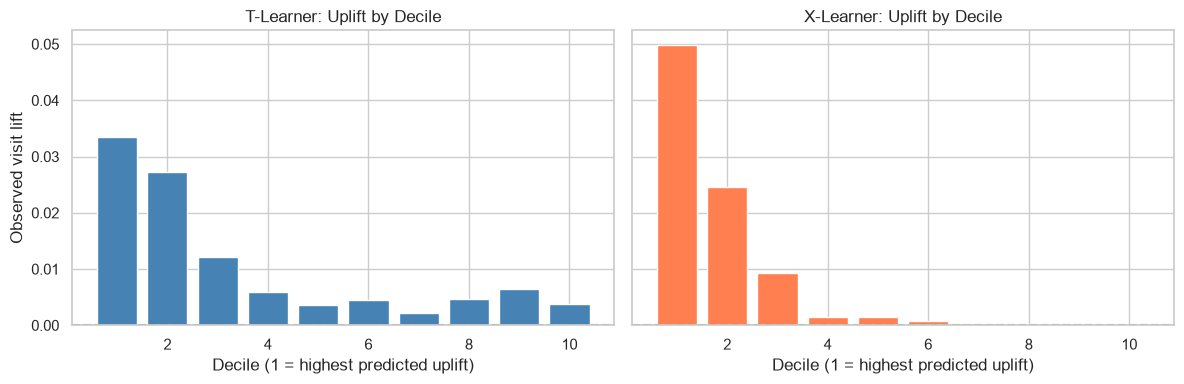

,decile,T-Learner,X-Learner
0,1,0.0335,0.0499
1,2,0.0273,0.0246
2,3,0.0121,0.0092
3,4,0.0060,0.0015
4,5,0.0036,0.0014
5,6,0.0046,0.0008
6,7,0.0023,0.0004
7,8,0.0046,0.0002
8,9,0.0065,0.0000
9,10,0.0037,0.0001


In [6]:
def uplift_by_decile(df, score_col="uplift"):
    d = df.copy()
    # rank users by predicted uplift score descending, then cut into 10 equal buckets
    d["rank"] = d[score_col].rank(ascending=False, method="first")
    d["decile"] = pd.qcut(d["rank"], q=10, labels=range(1, 11)).astype(int)
    # observed lift per bucket: actual visit rate difference between treatment and control
    grouped = (
        d.groupby("decile")
        .apply(lambda g: g.loc[g["treatment"] == 1, "y_true"].mean()
                       - g.loc[g["treatment"] == 0, "y_true"].mean())
        .reset_index(name="observed_lift")
    )
    return grouped

decile_t = uplift_by_decile(df_t)
decile_x = uplift_by_decile(df_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(decile_t["decile"], decile_t["observed_lift"], color="steelblue")
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("T-Learner: Uplift by Decile")
axes[0].set_xlabel("Decile (1 = highest predicted uplift)")
axes[0].set_ylabel("Observed visit lift")

axes[1].bar(decile_x["decile"], decile_x["observed_lift"], color="coral")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("X-Learner: Uplift by Decile")
axes[1].set_xlabel("Decile (1 = highest predicted uplift)")

plt.tight_layout()
plt.savefig("../images/uplift_by_decile.png", dpi=150, bbox_inches="tight")
plt.show()

summary = decile_t.rename(columns={"observed_lift": "T-Learner"}).merge(
    decile_x.rename(columns={"observed_lift": "X-Learner"}), on="decile"
)
summary["T-Learner"] = summary["T-Learner"].map("{:.4f}".format)
summary["X-Learner"] = summary["X-Learner"].map("{:.4f}".format)
summary

- **X-Learner:** observed lift drops sharply after decile 2 (0.0499 → 0.0246 → near zero), meaning persuadables are tightly concentrated in the top 20% of the ranking.
- **T-Learner:** signal spreads more loosely across deciles with noisy mid-range values (e.g. decile 8 at 0.0046), reflecting weaker separation between high and low uplift users.

## 6. Summary

X-Learner outperforms T-Learner across all evaluation lenses.

| Metric | T-Learner | X-Learner |
|---|---|---|
| Qini AUC | 0.0581 | 0.0853 |
| AUUC | 0.0228 | 0.0335 |
| Incremental visits at top 20% | 7,248 | 8,968 (+24%) |
| Decile 1 observed lift | 0.0335 | 0.0499 |

The advantage is largest when targeting a small fraction of users, which is the realistic budget-constrained scenario. At 20% targeting, X-Learner captures 24% more incremental visits. By 80%, the gap narrows to 8%, and both models converge at 100%.

The decile chart confirms why: X-Learner pushes more of the true persuadables into the top buckets, whereas T-Learner spreads signal more loosely across the ranking. This is consistent with X-Learner being designed for imbalanced treatment/control data (85/15 here), borrowing information across groups in a way T-Learner cannot.